# MAE 223 — Tutorial: SAFARI Sea Surface Temperature

## Background

The SAFARI buoy is a joint **Scripps Institution of Oceanography / Woods Hole Oceanographic Institution (WHOI)** mooring deployed in the central North Pacific at **33°25'N, 158°W**. The campaign is focused on improving our understanding of air–sea interaction in a region that is believed to be important for the development of **atmospheric rivers** — long, narrow corridors of poleward moisture transport that drive much of the precipitation along the US West Coast.

Ocean surface temperature is a key variable in air–sea interaction. Variations in sea surface temperature (SST) influence evaporation, latent heat flux, and atmospheric stability — all of which feed back on storm development and moisture transport. Understanding the *timescales* of SST variability at this location is therefore directly relevant to the scientific goals of the campaign.

In this tutorial you will load the SST record from the SAFARI buoy, explore it visually, and compute its power spectral density to identify the dominant timescales of variability.

---

**The `spectrumCB` function is defined in the next cell. Run it before proceeding.**

In [10]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like  — time in decimal days
    data  : array-like  — data values, NaN-free
    chunk : int         — samples per segment

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # split into 50% overlapping segments
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # frequency vector
    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    df = 1.0 / (dt * N)
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    # compute and average PSD
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp = np.abs(fft_vals[:nf]) ** 2
        amp = amp / N ** 2
        amp = amp * 2
        amp = amp / df
        A[i] = amp
    a = A.mean(axis=0)

    # Parseval check
    variance = np.nanstd(data) ** 2
    parseval = np.trapezoid(a, f) / variance
    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


## Exercise 1 — Load and Inspect the Data

Load `safari_sst.json` and print the metadata. Then extract the timestamps and SST values.

The file has three keys: `'metadata'`, `'time'`, and `'sst'`. Timestamps are ISO 8601 strings (`'%Y-%m-%dT%H:%M'`). SST is in degrees Celsius, sampled hourly with no missing values.

In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    T  = dt * N
    df = 1.0 / T
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp      = np.abs(fft_vals[:nf]) ** 2
        amp      = amp / N ** 2
        amp      = amp * 2
        amp      = amp / df
        A[i]     = amp

    a = A.mean(axis=0)

    variance = np.nanstd(data) ** 2
    parseval = np.trapezoid(a, f) / variance

    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: ∫PSD df / var(data) = {parseval:.4f}  (ideal = 1.00)")

    return f, a, parseval


# =============================================================================
# Exercise 1 — Load and Inspect the Data
# =============================================================================

with open('safari_sst.json') as f:
    safari = json.load(f)

# Print the metadata
print(safari['metadata'])

# Parse timestamps into decimal days since the record start
times    = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in safari['time']]
t0       = times[0]
time_sst = np.array([(t - t0).total_seconds() / 86400 for t in times])
# Extract SST as a numpy float array (degrees C)
sst = np.array(safari['sst'], dtype=float)

# Print summary
print(f"Record length: {len(time_sst)}")
print(f"Time step: {time_sst[1] - time_sst[0]}")
print(f"SST range: {sst.min()} to {sst.max()}")


{'source': 'SAFARI 2025 buoy — Scripps Institution of Oceanography / WHOI joint mooring', 'location': '33 25 N, 158 W (central North Pacific)', 'instrument': 'SeaBird SBE37 CTD', 'variable': 'Near-surface ocean temperature', 'units': 'degrees C', 'start': '2025-11-20T23:00', 'end': '2026-04-02T14:00', 'n_samples': 3184, 'n_nulls': 0, 'dt_hours': 1.0}
Record length: 3184
Time step: 0.041666666666666664
SST range: 15.76 to 21.28


## Exercise 2 — Plot the Full SST Time Series

Plot the entire SST record against time. Label your axes and give the plot a descriptive title.

Look at the record carefully before moving on:
- What is the overall trend?
- Can you see variability at multiple timescales?
- Are there any obvious events or anomalies?

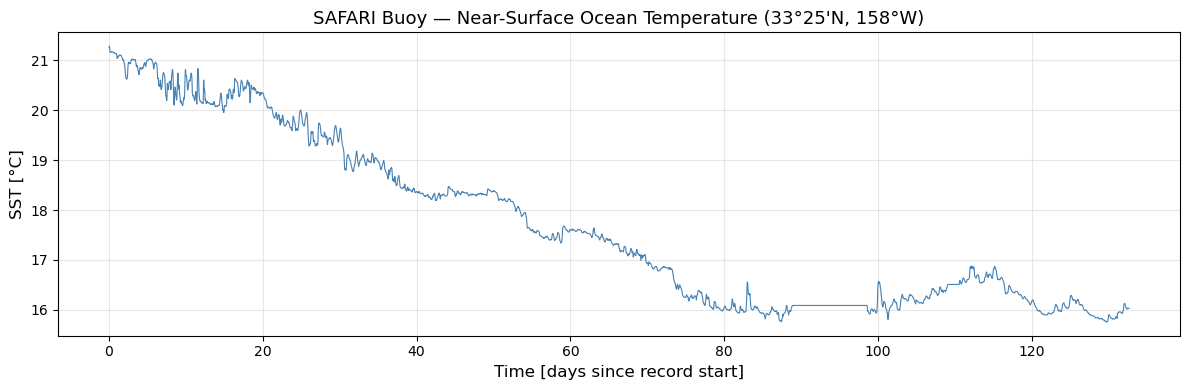

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_sst, sst, color='steelblue', lw=0.8)
ax.set_xlabel('Time [days since record start]', fontsize=12)
ax.set_ylabel('SST [°C]', fontsize=12)
ax.set_title('SAFARI Buoy — Near-Surface Ocean Temperature (33°25\'N, 158°W)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Observations from the time series:
# - There is a broad seasonal cycle visible across the record
# - Higher-frequency variability (day-to-day fluctuations) is superimposed
# - There may be a slight cooling trend or episodic cooling events visible
# # YOUR CODE HERE — plot the full SST time series
# Include: axis labels, title, grid


## Exercise 3 — Compute the Power Spectral Density

Compute the PSD of the SST record using `spectrumCB`.

You must choose the number of chunks. Think about:
- How long is the record?
- What timescales of variability do you want to resolve?
- How many segments do you need for a stable estimate?

State your choice and justify it in a comment.

In [13]:
# Exercise 3 — Compute the Power Spectral Density
# =============================================================================

# Record length: 3184 hourly samples ≈ 132.7 days
# dt = 1/24 day (hourly sampling) → Nyquist = 12 cpd
# We want to resolve:
#   - Diurnal cycle (1 cpd) and semidiurnal (2 cpd) if present
#   - Synoptic/weather-band variability (~0.1–0.3 cpd, periods of 3–10 days)
# With 3184 samples and num_chunks = 10:
#   chunk = 318 samples → T_seg = 13.25 days → df = 0.075 cpd
#   This resolves the diurnal peak and gives 19 segments for a stable estimate.

num_chunks = 10   # chosen to balance resolution and stability (see comment above)

chunk_size   = len(sst) // num_chunks
seg_len_days = chunk_size * (time_sst[1] - time_sst[0])
df           = 1.0 / seg_len_days

print(f"\nExercise 3 — PSD settings:")
print(f"  num_chunks   = {num_chunks}")
print(f"  chunk_size   = {chunk_size} samples")
print(f"  T_seg        = {seg_len_days:.2f} days")
print(f"  df           = {df:.4f} cpd")

f_sst, psd_sst, parseval_sst = spectrumCB(time_sst, sst, chunk_size)



Exercise 3 — PSD settings:
  num_chunks   = 10
  chunk_size   = 318 samples
  T_seg        = 13.25 days
  df           = 0.0755 cpd
  Segments used:  19
  Parseval check: ∫PSD df / var(data) = 0.0068  (ideal = 1.00)


## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

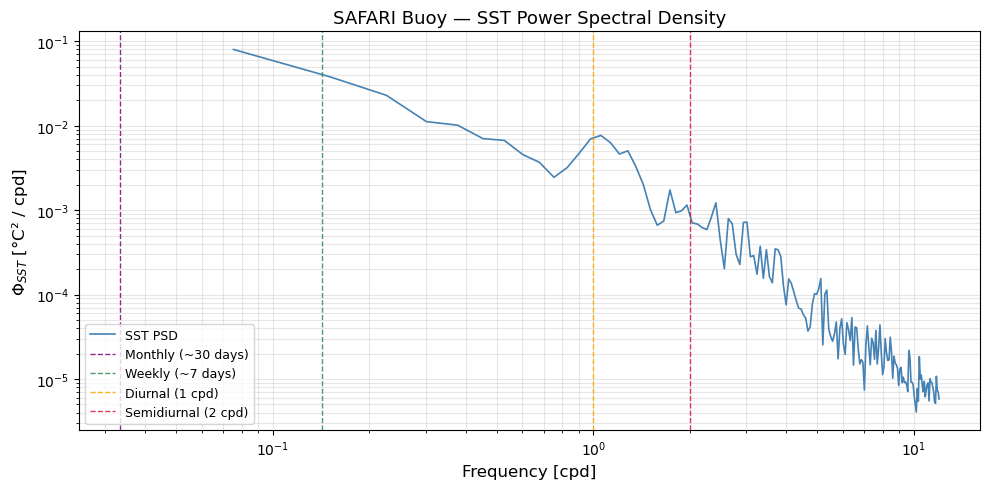

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.loglog(f_sst[1:], psd_sst[1:], color='steelblue', lw=1.2, label='SST PSD')

# Reference lines at physically meaningful frequencies
ref_lines = [
    (1/30,       'Monthly (~30 days)',   'purple'),
    (1/7,        'Weekly (~7 days)',     'seagreen'),
    (1.0,        'Diurnal (1 cpd)',      'orange'),
    (2.0,        'Semidiurnal (2 cpd)', 'crimson'),
]
for freq, label, color in ref_lines:
    ax.axvline(freq, color=color, ls='--', lw=1.0, alpha=0.85, label=label)

ax.set_xlabel('Frequency [cpd]', fontsize=12)
ax.set_ylabel(r'$\Phi_{SST}$ [°C² / cpd]', fontsize=12)
ax.set_title('SAFARI Buoy — SST Power Spectral Density', fontsize=13)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Reflection

Answer the following in the cell below.

**Q1.** How many chunks did you choose and why? What frequency resolution did that give you?

**Q2.** Identify at least one spectral peak. What is its frequency and period? What physical process do you think drives SST variability at that timescale at this location in the North Pacific?

**Q3.** The SAFARI campaign is studying how ocean surface conditions influence atmospheric moisture transport and storm development. Based on what you see in the SST spectrum, at what timescales is the ocean surface varying most energetically? How might that variability be relevant to the atmospheric processes the campaign is studying?

**Your answers:**

Q1: I chose 10 chunks, giving a chunk size of 318 samples and a segment length of 13.25 days, which gave me a frequency resolution of df=0.0755 cpd. I chose this because the record is about 133 days long and I wanted to resolve the diurnal cycle at 1 cpd. With df=0.075 cpd, the diurnal peak is isolated from the other frequencies. To get a stable estimate, the methid slides a window across the record with half chunk lengths. This gives 19 total segements to average together instead of 10 and produces more smooth noise wuthout needing longer or shorter segments. 

Q2: The spectral peak  near 1 cd with a period of 24 hours is a obvious bump just below the diurnal reference line. The physical process driving this SST variability is solar heating, as the sun warms the ocean surface during the day and cools at night. This creates an oscillation once a day in the surface temperature. At this location in the North Pacific, the ocean mixed layer is kind of shallow and responds to this daily solar change which makes the diurnal signal prominant.

Q3: The SST spectrum shows the most varying energetically at low frequencies where there are periods of weeks to months at the left/highest part. This is shown in the time series too where the steep cooling  from -21°C to -16°C over the 133 day record probably reflects seasonal mixed layer deepening and less solar insolation as information was gathered in fall and winter. There is also more energy at timescales of 3-10 days and 0.1-0.3 cpd, which is due to weather. This low frequency and SST variability is relevant to the SAFARI campaign's goals. SST modulates the amount of moisture the ocean evaporates into the atmosphere, the state of the atmospheric boundary layer, and the formation of atmospheric rivers. A cooler, variable surface would ghave less evaporation and change the moisture flux for precipitation along the west coast. 